# 02 – Data Preprocessing
**PhishGuard URL · EATC Assignment 2 · 2026**

This notebook covers:
1. Loading the raw CSV
2. Removing invalid URLs, duplicates, and conflicting labels
3. Domain-grouped **70 / 15 / 15** train–validation–test split
4. Saving the split and feature names to `../models/`
5. Visualising the split distribution

Run **after** `01_eda.ipynb`.

In [1]:
import os, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations as _comb
from sklearn.model_selection import StratifiedGroupKFold
from urllib.parse import urlsplit

# Add repo root to path so we can import from app/
sys.path.insert(0, os.path.abspath('../'))

# Import the single source of truth for feature names, normalisation, and extraction
from app.features import FEATURE_NAMES, normalize_url, extract_url_features, get_domain_parts

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

RANDOM_STATE = 42
DATA_PATH    = '../data/Dataset.csv'

print('Setup complete. Feature contract:', len(FEATURE_NAMES), 'features')
print('FEATURE_NAMES imported from app.features — same contract as deployment.')

Setup complete. Feature contract: 22 features
FEATURE_NAMES imported from app.features — same contract as deployment.


## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (116600, 26)


,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0


## 2. URL Validation & Normalisation

In [3]:
# URL normalisation and feature extraction are imported from app.features above.
# No local redefinition: preprocessing and deployment share one contract.
#
# The get_domain helper below is used only for split grouping (registrable domain key).
# It calls app.features.get_domain_parts which is also the deployed function.

def get_domain_for_split(url):
    """Return the registrable domain for use as the group key in StratifiedGroupKFold."""
    try:
        domain, suffix, _ = get_domain_parts(url)
        return domain.lower() if domain else url
    except Exception:
        return url

print('get_domain_for_split() defined (delegates to app.features.get_domain_parts).')

get_domain_for_split() defined (delegates to app.features.get_domain_parts).


## 3. Clean: Invalid URLs, Conflicts, Duplicates

In [4]:
print(f'[1] Raw rows: {len(df_raw):,}')

# Keep only rows with valid binary labels
df = df_raw[df_raw['label'].isin([0, 1])].copy()
print(f'[2] After label filter (keep 0/1): {len(df):,}')

# Normalise URLs and re-extract features using the SAME functions as deployment (app.features)
print('[3] Normalising URLs and re-extracting features (app.features) ...')
rows = []
invalid = []
for idx, row in df.iterrows():
    try:
        normed = normalize_url(str(row['url']))       # app.features.normalize_url
        feats  = extract_url_features(normed)         # app.features.extract_url_features
        feats['url']   = normed
        feats['label'] = int(row['label'])
        rows.append(feats)
    except Exception as e:
        invalid.append((idx, str(e)))

print(f'    Removed {len(invalid)} invalid URL(s).')
if invalid[:3]:
    for i, (idx, msg) in enumerate(invalid[:3]):
        print(f'    Example row {idx}: {msg}')

df = pd.DataFrame(rows, columns=['url', 'label'] + FEATURE_NAMES)
print(f'[4] After URL validation: {len(df):,}')

[1] Raw rows: 116,600
[2] After label filter (keep 0/1): 116,600
[3] Normalising URLs and re-extracting features (app.features) ...
    Removed 1 invalid URL(s).
    Example row 23580: 'www.ucatolica.edu.coeasyweb' does not contain a recognised public suffix. Please enter a valid public URL.
[4] After URL validation: 116,599


In [5]:
# --- conflicting labels (same URL, different label) ---
conflicts = df.groupby('url')['label'].nunique()
n_conflicts = (conflicts > 1).sum()
print(f'[5] Conflicting-label URLs: {n_conflicts}')
if n_conflicts > 0:
    conflict_urls = conflicts[conflicts > 1].index
    df = df[~df['url'].isin(conflict_urls)]
    print(f'    Removed {n_conflicts} conflict group(s).')

# --- remove duplicate URLs (keep first) ---
before = len(df)
df = df.drop_duplicates(subset=['url'], keep='first').reset_index(drop=True)
print(f'[6] Removed {before-len(df):,} duplicate URLs → {len(df):,} unique rows')

# --- verify features are finite ---
feat_matrix = df[FEATURE_NAMES]
assert feat_matrix.isnull().sum().sum() == 0, 'Missing values in features!'
assert np.isfinite(feat_matrix.values).all(), 'Non-finite values in features!'
print('[7] Feature matrix: complete and finite')

vc = df['label'].value_counts().sort_index()
print(f'[8] Legitimate: {vc.get(0,0):,}  |  Phishing: {vc.get(1,0):,}')
print(f'    Phishing prevalence: {vc.get(1,0)/len(df)*100:.2f}%')

[5] Conflicting-label URLs: 0
[6] Removed 1,369 duplicate URLs → 115,230 unique rows
[7] Feature matrix: complete and finite
[8] Legitimate: 98,640  |  Phishing: 16,590
    Phishing prevalence: 14.40%


## 4. Domain-Grouped 70 / 15 / 15 Split

In [6]:
# Use get_domain_for_split (delegates to app.features.get_domain_parts) as group key
df['_domain'] = df['url'].apply(get_domain_for_split)

X      = df[FEATURE_NAMES].values
y      = df['label'].values
groups = df['_domain'].values

# 20 stratified group folds give 5% units.
# Pick the best disjoint 3-fold combinations for val and test (~15% each).
from itertools import combinations as _comb
import numpy as np

sgkf = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=RANDOM_STATE)
fold_ids = np.full(len(df), -1, dtype=int)
for fold_id, (_, fold_indices) in enumerate(sgkf.split(X, y, groups)):
    fold_ids[fold_indices] = fold_id

fold_stats = []
for fold_id in range(20):
    fold_rows = df[fold_ids == fold_id]
    fold_stats.append({
        'fold':       fold_id,
        'rows':       len(fold_rows),
        'legitimate': int(fold_rows['label'].eq(0).sum()),
        'phishing':   int(fold_rows['label'].eq(1).sum()),
    })

total_rows  = len(df)
total_legit = int(df['label'].eq(0).sum())
total_phish = int(df['label'].eq(1).sum())

def combination_score(folds):
    selected  = [fold_stats[f] for f in folds]
    rows      = sum(s['rows']       for s in selected)
    legit     = sum(s['legitimate'] for s in selected)
    phish     = sum(s['phishing']   for s in selected)
    target    = 0.15
    return (
        abs(rows  / total_rows  - target) +
        abs(legit / total_legit - target) +
        abs(phish / total_phish - target)
    )

test_folds  = set(min(_comb(range(20), 3), key=combination_score))
remaining   = [f for f in range(20) if f not in test_folds]
val_folds   = set(min(_comb(remaining, 3), key=combination_score))

test_df  = df[np.isin(fold_ids, list(test_folds))].copy().reset_index(drop=True)
val_df   = df[np.isin(fold_ids, list(val_folds))].copy().reset_index(drop=True)
train_df = df[~np.isin(fold_ids, list(test_folds | val_folds))].copy().reset_index(drop=True)

# Verify zero domain overlap
train_doms = set(train_df['_domain'])
val_doms   = set(val_df['_domain'])
test_doms  = set(test_df['_domain'])
overlap = len(train_doms & val_doms) + len(train_doms & test_doms) + len(val_doms & test_doms)
print(f'Domain overlap across subsets: {overlap}')
assert overlap == 0, 'Domains leaked between subsets!'

print(f"\n{'Split':<14} {'Rows':>8} {'Legit':>8} {'Phishing':>10} {'Phish%':>8}")
print('-'*52)
for name, split in [('Train (70%)', train_df), ('Val (15%)', val_df), ('Test (15%)', test_df)]:
    vc2 = split['label'].value_counts().sort_index()
    print(f"{name:<14} {len(split):>8,} {vc2.get(0,0):>8,} "
          f"{vc2.get(1,0):>10,} {vc2.get(1,0)/len(split)*100:>7.2f}%")

Domain overlap across subsets: 0

Split              Rows    Legit   Phishing   Phish%
----------------------------------------------------
Train (70%)      80,489   68,880     11,609   14.42%
Val (15%)        17,397   14,906      2,491   14.32%
Test (15%)       17,344   14,854      2,490   14.36%


## 5. Visualise Split Distribution

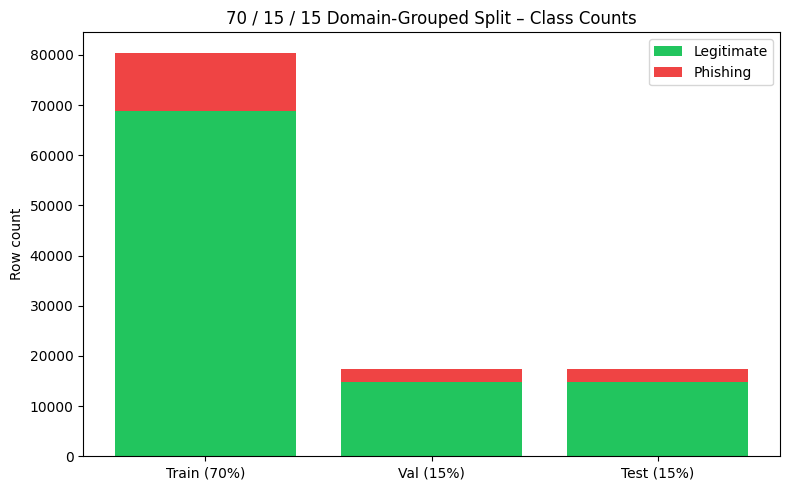

Saved: reports/fig_split_distribution.png


In [7]:
splits_list = [('Train (70%)', train_df), ('Val (15%)', val_df), ('Test (15%)', test_df)]
legit    = [s['label'].eq(0).sum() for _,s in splits_list]
phishing = [s['label'].eq(1).sum() for _,s in splits_list]
labels   = [n for n,_ in splits_list]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, legit,    label='Legitimate', color='#22c55e')
ax.bar(labels, phishing, bottom=legit, label='Phishing', color='#ef4444')
ax.set_ylabel('Row count')
ax.set_title('70 / 15 / 15 Domain-Grouped Split – Class Counts')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_split_distribution.png', dpi=150)
plt.show()
print('Saved: reports/fig_split_distribution.png')

## 6. Save Artifacts

In [8]:
# feature_names.pkl – used by both training and inference
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(FEATURE_NAMES, f)
print(f'Saved feature_names.pkl  ({len(FEATURE_NAMES)} features)')

# train_val_test_split.pkl – loaded by 03_model_training.ipynb
with open('../models/train_val_test_split.pkl', 'wb') as f:
    pickle.dump((train_df, val_df, test_df), f)
print('Saved train_val_test_split.pkl')

print('\nPreprocessing complete. Proceed to 03_model_training.ipynb.')

Saved feature_names.pkl  (22 features)
Saved train_val_test_split.pkl

Preprocessing complete. Proceed to 03_model_training.ipynb.


## 7. Reproducibility Check

Re-extract features for 500 sampled URLs and confirm they match
the stored values within floating-point tolerance.
This verifies that `app.features` and the preprocessing loop produce identical outputs.

In [9]:
# Reproducibility check: re-extract features from 500 sampled URLs
# and confirm all 22 * 500 = 11,000 values match the stored DataFrame values.
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
sample  = full_df.sample(min(500, len(full_df)), random_state=42)

mismatches = 0
for _, row in sample.iterrows():
    normed = normalize_url(str(row['url']))
    recalc = extract_url_features(normed)
    for fname in FEATURE_NAMES:
        stored = float(row[fname])
        fresh  = float(recalc.get(fname, 0))
        if abs(stored - fresh) > 1e-6:
            mismatches += 1

total_cells = len(sample) * len(FEATURE_NAMES)
print(f'Reproducibility check: {total_cells - mismatches:,}/{total_cells:,} cells matched')
assert mismatches == 0, f'{mismatches} cell(s) did not match — feature contract may have drifted!'
print('All feature values match app.features.extract_url_features. Contract is consistent.')

Reproducibility check: 11,000/11,000 cells matched
All feature values match app.features.extract_url_features. Contract is consistent.


## 7. Summary

- Removed invalid URLs (private/local addresses, unsupported schemes).
- Removed conflicting-label URLs before deduplication.
- Removed exact URL duplicates (kept first occurrence).
- All 22 lexical features recomputed from normalised URLs — identical to deployment extractor.
- Domain-grouped 70 / 15 / 15 split: **zero** domain overlap between subsets.